# Class 6: Consequence
## GIS Vulnerability & Risk Assessment

**Objective:** Score the consequence of flooding based on structure value.

In this lesson, you will learn:
- What "consequence" means in risk assessment
- How structure value indicates the severity of potential damage
- How to use the median as a decision threshold
- How to classify parcels into consequence categories

## What is Consequence?

**Consequence** is the **severity of impact** if an event occurs.

Think of it this way:
- If a flood damages a vacant lot → low consequence (nothing valuable there to damage)
- If a flood damages a modest house → medium consequence (some value at risk)
- If a flood damages a luxury home → high consequence (significant value at risk)

In this course, we measure consequence using **structure value** (the monetary worth of buildings on the parcel).

### Why Structure Value?

Structures represent the most significant financial asset typically exposed to flooding in a property. The more valuable the structure, the greater the potential financial loss if it is damaged.

## Understanding the Median

The **median** is the "middle value" that divides a dataset in half:
- 50% of values fall **below** the median
- 50% of values fall **above** the median

**Why use the median instead of the average (mean)?**

Imagine your study area has:
- 100 modest houses worth $150,000 each
- 1 mansion worth $10,000,000

The **mean** would be: (100 × $150,000 + $10,000,000) / 101 = **$247,525**
- This is skewed by the one expensive property!

The **median** would be: **$150,000**
- This represents a typical property value
- It is more resistant to extreme outliers

The median is more representative of a typical property in your study area.

## Consequence Scoring Rules

We will classify each parcel into one of four categories:

| Score | Category | Rule |
|-------|----------|------|
| **0** | Not Exposed | Parcel is in a flood-safe zone (no exposure) |
| **1** | Low | Parcel is exposed BUT has no building (land only) |
| **2** | Medium | Parcel AND building are exposed, structure value at or below median value |
| **3** | High | Parcel AND building are exposed, structure value above median value |

**Key insight:** You need TWO things for medium or high consequence:
1. The parcel must be in the flood zone (exposure > 0)
2. There must be a building on it (structure value > 0)

## Install Libraries and Set Up

We will use these Python libraries:
- **geopandas**: Work with geographic data and shapefiles/GeoPackages
- **pandas**: Organize and analyze tabular data
- **matplotlib**: Create visualizations
- **folium**: Create interactive maps
- **numpy**: Numerical calculations

In [14]:
!pip install geopandas fiona shapely pyproj requests folium seaborn contextily --quiet
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium
import os
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('seaborn-v0_8-darkgrid')
print("✓ All libraries loaded successfully!")


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
✓ All libraries loaded successfully!


## Mount Google Drive

This connects your Colab notebook to your Google Drive, allowing you to read and save files.

In [ ]:
# === ENVIRONMENT SETUP ===
import os

try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/MSER_510_VULNERABILTY'
    print("Google Drive connected!")
except Exception:
    BASE_DIR = './'
    print("Running locally.")

DATA_DIR = os.path.join(BASE_DIR, 'data')
OUTPUT_DIR = os.path.join(BASE_DIR, 'outputs')

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# GeoPackage file paths for chained loading
INPUT_GPKG = os.path.join(DATA_DIR, 'class_5_probability.gpkg')  # Load from Class 5
OUTPUT_GPKG = os.path.join(DATA_DIR, 'class_6_consequence.gpkg')  # Save to Class 6
CLASS0_GPKG = os.path.join(DATA_DIR, 'vulnerability_risk_data.gpkg')  # Fallback for base layers

print(f"  Base directory: {BASE_DIR}")
print(f"  Data directory: {DATA_DIR}")
print(f"  Output directory: {OUTPUT_DIR}")

## Load Parcel Data

We will load the parcels layer from the GeoPackage. This should contain:
- Parcel boundaries (geometry)
- An **exposure** field from Class 2 (0 = not exposed, 1 = exposed to flooding)
- A **structure value** field (e.g., structure_value) indicating the monetary value of buildings

In [17]:
# List all layers in the GeoPackage to see what we have
print("Available layers in INPUT GeoPackage:")
try:
    layers = gpd.io.file.fiona.listlayers(INPUT_GPKG)
    for layer in layers:
        print(f"  - {layer}")
except Exception as e:
    print(f"Error reading layers: {e}")

# Load the parcels layer from INPUT GeoPackage (from Class 5)
parcels = gpd.read_file(INPUT_GPKG, layer='parcels')
print(f"\n✓ Loaded {len(parcels)} parcels from Class 5")
print(f"\nColumns in dataset:")
print(parcels.columns.tolist())

Available layers in INPUT GeoPackage:
Error reading layers: 'NoneType' object has no attribute 'listlayers'

✓ Loaded 16078 parcels from Class 5

Columns in dataset:
['objectid', 'parno', 'altparno', 'ownname', 'improvval', 'landval', 'parval', 'mailadd', 'munit', 'mcity', 'mstate', 'mzip', 'siteadd', 'sunit', 'scity', 'gisacres', 'struct', 'multistruc', 'saledate', 'saledatetx', 'legdecfull', 'parusecode', 'parusedesc', 'parusecd2', 'parusedsc2', 'parvaltype', 'owntype', 'recareano', 'recareatx', 'revisedate', 'sourceref', 'sourcedate', 'sourcedatx', 'subdivisio', 'nparno', 'cntyname', 'cntyfips', 'stfips', 'stcntyfips', 'gnisid', 'sourceagnt', 'transfdate', 'maddpref', 'maddrno', 'maddstname', 'maddstr', 'maddstsuf', 'maddsttyp', 'ownfrst', 'ownlast', 'revdatetx', 'reviseyear', 'saddno', 'saddpref', 'saddstname', 'saddstr', 'saddstsuf', 'saddsttyp', 'sstate', 'stname', 'subowntype', 'subsurfown', 'szip', 'structno', 'structyear', 'ownname2', 'presentval', 'mapref', 'st_area(shape)', 

## Explore the Structure Value Field

Before we calculate consequence, let us understand the structure value data.
We need to identify which column contains structure values.

Common column names include: structure_value, etc.

In [18]:
# Look for structure value columns (case-insensitive)
value_columns = [col for col in parcels.columns if 'value' in col.lower() or 'val' in col.lower() or 'build' in col.lower()]
print(f"Potential value columns: {value_columns}")

# Try to find the primary structure value column
# Priority: structure_value``, then structure_value, then others
if 'structure_value' in parcels.columns:
    value_col = 'structure_value'
elif 'structure_value' in parcels.columns:
    value_col = 'structure_value'
elif 'structure_value' in parcels.columns:
    value_col = 'structure_value'
elif value_columns:
    value_col = value_columns[0]
    print(f"Using column: {value_col}")
else:
    print("⚠ Warning: Could not find a structure value column!")
    value_col = None

if value_col:
    print(f"\n✓ Using '{value_col}' as the structure value field")
else:
    print("\nPlease manually specify the structure value column name:")
    print("value_col = 'YOUR_COLUMN_NAME'")

Potential value columns: ['improvval', 'landval', 'parval', 'parvaltype', 'presentval', 'building_exposed', 'structure_value']

✓ Using 'structure_value' as the structure value field


## Check for Exposure Field

We need an **exposure** field from Class 2 to know which parcels are in the flood zone.

In [19]:
# Check if exposure field exists
if 'exposure' in parcels.columns:
    print("✓ Found 'exposure' field")
    print(f"\nExposure field summary:")
    print(parcels['exposure'].value_counts().sort_index())
else:
    print("⚠ Warning: 'exposure' field not found")
    print("Available columns:", parcels.columns.tolist())
    print("\nPlease ensure Class 2 (Exposure) was completed first.")

✓ Found 'exposure' field

Exposure field summary:
exposure
0    13849
1     2229
Name: count, dtype: int64


## Summary Statistics for Structure Values

Let us explore the distribution of structure values in our study area.

This helps us understand:
- How many parcels have buildings vs. land-only
- The range of building values
- Where the median falls

In [20]:
# Remove null/zero values for exploration (these are land-only parcels)
parcels_with_buildings = parcels[parcels[value_col] > 0].copy()

print(f"Parcels with buildings: {len(parcels_with_buildings):,} out of {len(parcels):,}")
print(f"Land-only parcels (value = 0 or null): {len(parcels) - len(parcels_with_buildings):,}")

if len(parcels_with_buildings) > 0:
    print(f"\n--- Structure Value Statistics ---")
    print(f"Minimum:  ${parcels_with_buildings[value_col].min():,.0f}")
    print(f"Maximum:  ${parcels_with_buildings[value_col].max():,.0f}")
    print(f"Mean:     ${parcels_with_buildings[value_col].mean():,.0f}")
    print(f"Median:   ${parcels_with_buildings[value_col].median():,.0f}")
    print(f"Std Dev:  ${parcels_with_buildings[value_col].std():,.0f}")
    print(f"\nPercentiles:")
    for pct in [10, 25, 50, 75, 90]:
        val = parcels_with_buildings[value_col].quantile(pct/100)
        print(f"  {pct}th percentile: ${val:,.0f}")

Parcels with buildings: 12,902 out of 16,078
Land-only parcels (value = 0 or null): 3,176

--- Structure Value Statistics ---
Minimum:  $100
Maximum:  $75,761,200
Mean:     $348,353
Median:   $210,850
Std Dev:  $1,746,364

Percentiles:
  10th percentile: $83,310
  25th percentile: $144,400
  50th percentile: $210,850
  75th percentile: $300,575
  90th percentile: $431,300


## Visualize Structure Value Distribution

A histogram shows us how building values are distributed. This is a great way to understand your data!

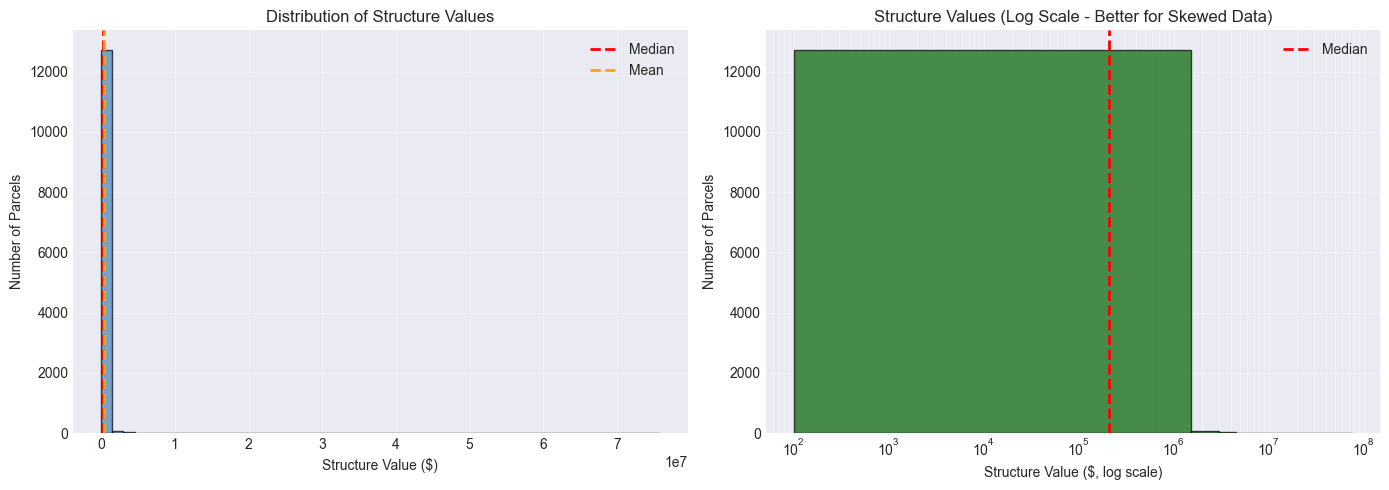

The histogram shows how structure values are distributed.
Notice: Most values cluster on the left (lower values),
with a long tail extending right (very expensive properties).
This is why the MEDIAN is more useful than the MEAN!


In [21]:
# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of all values (with buildings)
axes[0].hist(parcels_with_buildings[value_col], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(parcels_with_buildings[value_col].median(), color='red', linestyle='--', linewidth=2, label='Median')
axes[0].axvline(parcels_with_buildings[value_col].mean(), color='orange', linestyle='--', linewidth=2, label='Mean')
axes[0].set_xlabel('Structure Value ($)')
axes[0].set_ylabel('Number of Parcels')
axes[0].set_title('Distribution of Structure Values')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Log scale histogram (better for skewed data)
axes[1].hist(parcels_with_buildings[value_col], bins=50, color='darkgreen', edgecolor='black', alpha=0.7)
axes[1].set_xscale('log')
axes[1].axvline(parcels_with_buildings[value_col].median(), color='red', linestyle='--', linewidth=2, label='Median')
axes[1].set_xlabel('Structure Value ($, log scale)')
axes[1].set_ylabel('Number of Parcels')
axes[1].set_title('Structure Values (Log Scale - Better for Skewed Data)')
axes[1].legend()
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print("The histogram shows how structure values are distributed.")
print("Notice: Most values cluster on the left (lower values),")
print("with a long tail extending right (very expensive properties).")
print("This is why the MEDIAN is more useful than the MEAN!")

## Calculate the Median Structure Value (Separately for Each Asset Group)

We calculate **separate medians** for Asset 1 and Asset 2 parcels.
Each asset group uses its own median as the threshold for consequence scoring.

In [22]:
# Calculate separate medians for each asset group
# Only parcels with buildings (structure_value > 0) are included in the median

# Ensure asset flags exist
for col in ['is_asset_1', 'is_asset_2']:
    if col not in parcels.columns:
        print(f"WARNING: {col} not found — please ensure Class 1 was run first")

# Asset 1 median
a1_with_bldg = parcels[(parcels['is_asset_1'] == 1) & (parcels[value_col] > 0)]
median_a1 = a1_with_bldg[value_col].median() if len(a1_with_bldg) > 0 else 0

# Asset 2 median
a2_with_bldg = parcels[(parcels['is_asset_2'] == 1) & (parcels[value_col] > 0)]
median_a2 = a2_with_bldg[value_col].median() if len(a2_with_bldg) > 0 else 0

print(f"{'='*60}")
print(f"MEDIAN STRUCTURE VALUES (separate per asset group):")
print(f"{'='*60}")
print(f"  Asset 1: ${median_a1:,.0f}  ({len(a1_with_bldg):,} parcels with buildings)")
print(f"  Asset 2: ${median_a2:,.0f}  ({len(a2_with_bldg):,} parcels with buildings)")
print(f"\nThese are the thresholds for consequence scoring per asset group.")

## Calculate Consequence Score (Separately for Each Asset Group)

Each asset group uses its own median structure value as the threshold.
Only parcels belonging to an asset group are scored; others get 0.

This produces: `consequence_a1` and `consequence_a2`.

In [23]:
def calculate_consequence(row, median_val, value_col):
    """Calculate consequence score for a parcel."""
    if row['exposure'] == 0:
        return 0
    building_value = row[value_col]
    if pd.isna(building_value) or building_value == 0:
        return 1  # Low: land only
    if building_value <= median_val:
        return 2  # Medium: below median
    else:
        return 3  # High: above median

# Score each asset group separately with its own median
print("Calculating consequence scores separately for each asset group...")

# Asset 1
parcels['consequence_a1'] = parcels.apply(
    lambda row: calculate_consequence(row, median_a1, value_col) if row['is_asset_1'] == 1 else 0,
    axis=1
)

# Asset 2
parcels['consequence_a2'] = parcels.apply(
    lambda row: calculate_consequence(row, median_a2, value_col) if row['is_asset_2'] == 1 else 0,
    axis=1
)

labels = {0: 'Not Exposed/Not Scored', 1: 'Low (Land Only)', 2: 'Medium', 3: 'High'}
for col, label, med in [('consequence_a1', 'Asset 1', median_a1), ('consequence_a2', 'Asset 2', median_a2)]:
    asset_flag = 'is_asset_1' if 'a1' in col else 'is_asset_2'
    in_group = parcels[parcels[asset_flag] == 1]
    print(f"\n{label} (median=${med:,.0f}, {len(in_group):,} parcels):")
    for score in sorted(in_group[col].unique()):
        count = (in_group[col] == score).sum()
        pct = 100 * count / len(in_group)
        print(f"  {labels.get(score, '?')} ({score}): {count:,} ({pct:.1f}%)")

## Consequence Summary Statistics

Let us analyze the consequences in detail, broken down by score category.

In [24]:
# Create a summary table for each asset group
labels = {0: 'Not Exposed/Not Scored', 1: 'Low (Land Only)', 2: 'Medium', 3: 'High'}

for col, group_label, asset_flag in [
    ('consequence_a1', 'Asset 1', 'is_asset_1'),
    ('consequence_a2', 'Asset 2', 'is_asset_2'),
]:
    in_group = parcels[parcels[asset_flag] == 1].copy()
    summary = in_group.groupby(col).agg(
        Parcel_Count=('geometry', 'count'),
        Total_Structure_Value=(value_col, 'sum'),
        Avg_Structure_Value=(value_col, 'mean'),
        Min_Value=(value_col, 'min'),
        Max_Value=(value_col, 'max'),
    ).round(0)
    summary['Avg_Structure_Value'] = summary['Avg_Structure_Value'].astype('int64')
    summary.index = summary.index.map(labels)

    print('\n' + '=' * 80)
    print(f'CONSEQUENCE SUMMARY — {group_label}')
    print('=' * 80)
    print(summary.to_string())

    # Percentage breakdown
    print(f'\n  Percentage breakdown ({group_label}):')
    total = len(in_group)
    for score in sorted(in_group[col].unique()):
        count = (in_group[col] == score).sum()
        pct = (count / total) * 100
        print(f'    {labels[score]:.<30} {pct:>6.2f}% ({count:,} parcels)')

    # Exposed parcels only
    exposed = in_group[in_group['exposure'] > 0]
    print(f'\n  Exposed parcels in {group_label}: {len(exposed):,}')
    if len(exposed) > 0:
        for score in [1, 2, 3]:
            count = (exposed[col] == score).sum()
            pct = (count / len(exposed)) * 100
            print(f'    {labels[score]:.<25} {count:,} ({pct:.1f}%)')


## Create Interactive Map

This map shows parcels colored by consequence level:
- **Gray**: Not exposed (consequence = 0)
- **Green**: Low consequence (land only, consequence = 1)
- **Yellow**: Medium consequence (below-median structure value, consequence = 2)
- **Red**: High consequence (above-median structure value, consequence = 3)

Click on any parcel to see its details.

In [25]:
from IPython.display import HTML

# Define colors for each consequence level
consequence_colors = {
    0: '#757575',     # Gray - Not exposed
    1: '#FFCC80',     # Light orange - Low
    2: '#FF8A65',     # Orange - Medium
    3: '#D32F2F'      # Red - High
}

consequence_labels = {
    0: 'Not Exposed',
    1: 'Low (Land Only)',
    2: 'Medium (Below Median Value)',
    3: 'High (Above Median Value)'
}

# Calculate map center
bounds = parcels.total_bounds
center_lat = (bounds[1] + bounds[3]) / 2
center_lon = (bounds[0] + bounds[2]) / 2

# Create base map
m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=12,
    tiles='https://{s}.basemaps.cartocdn.com/dark_all/{z}/{x}/{y}{r}.png',
    attr='CartoDB',
    width='100%',
    height='450px'
)

# Create separate feature groups for each asset
fg_a1 = folium.FeatureGroup(name='Asset 1 — Consequence', show=True)
fg_a2 = folium.FeatureGroup(name='Asset 2 — Consequence', show=False)

for asset_col, asset_flag, median_val, fg in [
    ('consequence_a1', 'is_asset_1', median_a1, fg_a1),
    ('consequence_a2', 'is_asset_2', median_a2, fg_a2),
]:
    subset = parcels[parcels[asset_flag] == 1]
    print(f'Adding {len(subset)} parcels for {asset_col}...')
    for idx, row in subset.iterrows():
        if row['geometry'].geom_type == 'Polygon':
            coords = list(row['geometry'].exterior.coords)
            lat_lon_coords = [[lat, lon] for lon, lat in coords]

            color = consequence_colors.get(row[asset_col], '#757575')
            consequence_text = consequence_labels.get(row[asset_col], 'Unknown')

            popup_text = (
                f'<b>Consequence: {consequence_text}</b><br>'
                f'Score: {int(row[asset_col])}<br>'
                f'Exposure: {int(row.get("exposure", 0))}<br>'
                f'Structure Value: ${row[value_col]:,.0f}<br>'
                f'Median Threshold: ${median_val:,.0f}'
            )

            folium.Polygon(
                locations=lat_lon_coords,
                color='#00e5ff',
                weight=1,
                opacity=0.7,
                fill=True,
                fillColor=color,
                fillOpacity=0.6,
                popup=folium.Popup(popup_text, max_width=250)
            ).add_to(fg)

fg_a1.add_to(m)
fg_a2.add_to(m)
folium.LayerControl(collapsed=False).add_to(m)

# Add legend
legend_text = (
    '<div style="position: fixed; bottom: 50px; right: 50px; width: 240px; '
    'height: 200px; background-color: #2b2b2b; border:2px solid #00e5ff; '
    'z-index:9999; font-size:14px; padding: 10px; border-radius: 5px; '
    'color: white;">'
    '<b style="font-size: 16px;">Consequence Legend</b><br>'
    '<i style="background: #757575; padding: 2px 5px; border-radius: 3px;">SQUARE</i> Not Exposed (0)<br>'
    '<i style="background: #FFCC80; padding: 2px 5px; border-radius: 3px;">SQUARE</i> Low - Land Only (1)<br>'
    '<i style="background: #FF8A65; padding: 2px 5px; border-radius: 3px;">SQUARE</i> Medium (2)<br>'
    '<i style="background: #D32F2F; padding: 2px 5px; border-radius: 3px;">SQUARE</i> High (3)<br>'
    '<hr style="margin: 5px 0; border-color: #555555;">'
    '<b>Use layer control to toggle Asset 1 / Asset 2</b>'
    '</div>'
)
m.get_root().html.add_child(folium.Element(legend_text))

print(f'Map created with layer control for Asset 1 and Asset 2')

map_html = m._repr_html_()
display(HTML(f'<div style="height:450px;overflow:hidden;">{map_html}</div>'))


In [26]:
import contextily as ctx
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec

# Reproject to Web Mercator for basemap tiles
parcels_wm = parcels.to_crs(epsg=3857)

# Create figure with two map panels side-by-side + shared legend below
fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(2, 2, height_ratios=[10, 1.2], hspace=0.05, wspace=0.05)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax_legend = fig.add_subplot(gs[1, :])

consequence_colors = {1: '#FFCC80', 2: '#FF8A65', 3: '#D32F2F'}

for ax, col, asset_flag, title in [
    (ax1, 'consequence_a1', 'is_asset_1', 'Consequence — Asset 1'),
    (ax2, 'consequence_a2', 'is_asset_2', 'Consequence — Asset 2'),
]:
    # Layer 1: All parcels - thin grey borders
    parcels_wm.plot(ax=ax, facecolor='none', edgecolor='#888888', linewidth=0.3)

    # Layer 2: Consequence scores for this asset group
    in_group = parcels_wm[parcels_wm[asset_flag] == 1]
    for score in [3, 2, 1]:
        subset = in_group[in_group[col] == score]
        if len(subset) > 0:
            subset.plot(ax=ax, facecolor=consequence_colors[score], edgecolor='none', alpha=0.85)

    # Layer 3: Buildings
    try:
        buildings_layer = gpd.read_file(CLASS0_GPKG, layer='buildings')
        buildings_wm = buildings_layer.to_crs(epsg=3857)
        buildings_wm.plot(ax=ax, facecolor='#3D3D3D', edgecolor='#2a2a2a', linewidth=0.1, alpha=0.7)
    except Exception:
        pass

    # Layer 4: Flood zones
    try:
        flood_zones_full = gpd.read_file(CLASS0_GPKG, layer='flood_zones')
        flood_wm = flood_zones_full.to_crs(epsg=3857)
        flood_colors = {'Floodway': '#2B5797', '100-year': '#8FABBE', '500-year': '#B4D4E7'}
        for flood_type in ['500-year', '100-year', 'Floodway']:
            flood_subset = flood_wm[flood_wm['flood_category'] == flood_type]
            if len(flood_subset) > 0:
                flood_subset.plot(ax=ax, facecolor=flood_colors.get(flood_type, '#B4D4E7'),
                                edgecolor='none', alpha=0.5)
    except Exception:
        pass

    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom='auto')
    ax.set_axis_off()
    ax.set_title(title, fontsize=14, fontweight='bold', pad=10)

# Shared legend
ax_legend.set_axis_off()
legend_elements = [
    Patch(facecolor='#D32F2F', edgecolor='none', label='High (3)'),
    Patch(facecolor='#FF8A65', edgecolor='none', label='Medium (2)'),
    Patch(facecolor='#FFCC80', edgecolor='none', label='Low (1)'),
    Patch(facecolor='none', edgecolor='none', label=''),
    Patch(facecolor='#3D3D3D', edgecolor='#2a2a2a', label='Buildings'),
    Patch(facecolor='#2B5797', edgecolor='none', alpha=0.5, label='Floodway'),
    Patch(facecolor='#8FABBE', edgecolor='none', alpha=0.5, label='100-year Floodplain'),
    Patch(facecolor='#B4D4E7', edgecolor='none', alpha=0.5, label='500-year Floodplain'),
    Patch(facecolor='none', edgecolor='#888888', linewidth=0.5, label='Parcels'),
]
ax_legend.legend(handles=legend_elements, loc='center', ncol=4, fontsize=9,
                frameon=True, facecolor='white', edgecolor='#cccccc',
                handlelength=1.5, handletextpad=0.5, columnspacing=1.5)

# Export
OUTPUT_DIR = os.path.join(BASE_DIR, 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)
png_path = os.path.join(OUTPUT_DIR, 'consequence_map.png')
plt.savefig(png_path, dpi=150, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()
print(f'Map exported to: {png_path}')


## Step 5: Export Consequence Map as PNG

Now we'll create a publication-quality PNG map that combines all layers in the proper order with dark styling. This map shows consequence assessment with all supporting layers (buildings, flood zones, and parcels) in a single exportable image.

## Save Results to GeoPackage

We save the separate consequence scores (`consequence_a1`, `consequence_a2`) to the GeoPackage.
Class 7 will combine these with probability to calculate risk for each asset group.

In [27]:
try:
    import fiona
    import sqlite3
    
    # Save parcels layer first (creates new GeoPackage)
    parcels.to_file(OUTPUT_GPKG, layer='parcels', driver='GPKG', mode='w')
    print(f"✓ Saved parcels layer with consequence ({len(parcels)} features)")
    
    # Copy forward all other layers from the input GeoPackage
    if os.path.exists(INPUT_GPKG):
        input_layers = fiona.listlayers(INPUT_GPKG)
        for layer_name in input_layers:
            if layer_name == 'parcels':
                continue  # Already saved updated version
            try:
                layer_data = gpd.read_file(INPUT_GPKG, layer=layer_name)
                layer_data.to_file(OUTPUT_GPKG, layer=layer_name, driver='GPKG', mode='a')
                print(f"✓ Copied layer: {layer_name} ({len(layer_data)} features)")
            except Exception as e:
                print(f"  Note: Could not copy layer '{layer_name}' as spatial: {e}")
        
        # Also copy any non-spatial tables (like 'summary') via sqlite3
        try:
            conn_in = sqlite3.connect(INPUT_GPKG)
            conn_out = sqlite3.connect(OUTPUT_GPKG)
            cursor = conn_in.cursor()
            # Get all tables that aren't in fiona's layer list and aren't system tables
            cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
            all_tables = [row[0] for row in cursor.fetchall()]
            system_tables = ['gpkg_contents', 'gpkg_geometry_columns', 'gpkg_spatial_ref_sys',
                            'gpkg_ogr_contents', 'gpkg_tile_matrix', 'gpkg_tile_matrix_set',
                            'sqlite_sequence', 'gpkg_extensions', 'gpkg_metadata',
                            'gpkg_metadata_reference']
            for table in all_tables:
                if table in system_tables or table in input_layers or table.startswith('rtree_') or table.startswith('trigger_'):
                    continue
                try:
                    df = pd.read_sql(f'SELECT * FROM "{table}"', conn_in)
                    if len(df) > 0:
                        df.to_sql(table, conn_out, if_exists='replace', index=False)
                        print(f"✓ Copied non-spatial table: {table} ({len(df)} rows)")
                except Exception:
                    pass
            conn_in.close()
            conn_out.close()
        except Exception:
            pass
    
    # Also ensure base layers from Class 0 are included (flood_zones, buildings, study_area)
    # These may not be in INPUT_GPKG if earlier classes didn't carry them forward
    if os.path.exists(CLASS0_GPKG):
        try:
            import fiona as _fiona
            # Get layers already written to output
            output_layers = _fiona.listlayers(OUTPUT_GPKG)
            # Get layers available in Class 0
            class0_layers = _fiona.listlayers(CLASS0_GPKG)
            # Copy any missing layers
            for layer_name in class0_layers:
                if layer_name not in output_layers:
                    try:
                        layer_data = gpd.read_file(CLASS0_GPKG, layer=layer_name)
                        layer_data.to_file(OUTPUT_GPKG, layer=layer_name, driver='GPKG', mode='a')
                        print(f"✓ Added base layer from Class 0: {layer_name} ({len(layer_data)} features)")
                    except Exception as e:
                        print(f"  Note: Could not copy base layer '{layer_name}': {e}")
        except Exception:
            pass
    
    print(f"\n✓ All data saved to: {OUTPUT_GPKG}")
except Exception as e:
    print(f"✗ Error saving to GeoPackage: {e}")
    print("\nAlternative: Save to a new GeoPackage file")
    alt_path = os.path.join(DATA_DIR, 'class_6_consequence_backup.gpkg')
    parcels.to_file(alt_path, layer='parcels', driver='GPKG')
    print(f"✓ Saved to: {alt_path}")

✓ Saved parcels layer with consequence (16078 features)
✓ Copied layer: flood_zones_100yr (3250 features)
✓ Copied layer: study_area (13 features)
✓ Copied layer: flood_zones (3029 features)
✓ Copied layer: buildings (288886 features)

✓ All data saved to: ./data/class_6_consequence.gpkg


## Doing This in QGIS

### Step 1: Calculate the Median
1. Open your parcels layer in QGIS
2. Go to **Vector > Analysis Tools > Statistics for Fields**
3. Select your structure value field (e.g., structure_value)
4. Note the **median** value shown in the results window
   - Or use the built-in Statistics panel: **View > Panels > Statistics**

### Step 2: Add a New Field
1. Right-click the layer > **Properties > Fields**
2. Click the green **+** button to add a new field
3. Name: `consequence_a1` / `consequence_a2`
4. Type: Integer
5. Click **OK** and then **OK** again

### Step 3: Use Field Calculator
1. Right-click the layer > **Open Attribute Table**
2. Click **Open field calculator** (function icon in toolbar)
3. Check **Create a new field**
4. Output field: `consequence_a1` / `consequence_a2`
5. Output field type: Integer

### Step 4: Enter the Expression
Copy and paste this expression, replacing [MEDIAN_VALUE] with your actual median value:

```sql
CASE
  WHEN "exposure" = 0 THEN 0
  WHEN "structure_value" IS NULL OR "structure_value" = 0 THEN 1
  WHEN "structure_value" <= [MEDIAN_VALUE] THEN 2
  WHEN "structure_value" > [MEDIAN_VALUE] THEN 3
  ELSE 0
END
```

**Example** (if median is $250000):
```sql
CASE
  WHEN "exposure" = 0 THEN 0
  WHEN "structure_value" IS NULL OR "structure_value" = 0 THEN 1
  WHEN "structure_value" <= 250000 THEN 2
  WHEN "improvval" > 250000 THEN 3
  ELSE 0
END
```

### Step 5: Style the Results
1. Right-click layer > **Properties > Symbology**
2. Choose **Categorized**
3. Column: `consequence_a1` / `consequence_a2`
4. Set colors:
   - 0 = Gray (Not Exposed)
   - 1 = Green (Low)
   - 2 = Yellow (Medium)
   - 3 = Red (High)

> **Note:** You will need to repeat these steps for each asset group. The field names above use the Asset 1 suffix (`_a1`). For Asset 2, replace `_a1` with `_a2` in all field references.

## Doing This in ArcGIS Pro

### Step 1: Calculate the Median
1. Open your parcels feature class
2. Go to **Analysis > Statistics > Summarize** or use **Geoprocessing > Summarize Table**
3. Input Table: parcels
4. Output Table: (name it `summary_stats`)
5. Summary Fields: Add your structure value field with **Median** statistic
6. Review the output to get the median value

### Step 2: Add a New Field
1. In the **Attribute Table**, click **Fields** tab
2. Click **New Field**
3. Field Name: `consequence_a1` / `consequence_a2`
4. Data Type: **Short Integer**
5. Click **Save**

### Step 3: Use the Field Calculator
1. Right-click the `consequence_a1` / `consequence_a2` field > **Calculate Field**
2. Expression Type: **Python 3**
3. Paste the code below (replace [MEDIAN_VALUE] with your median):

```python
def calc_consequence(exposure, bldgvalue, median_val):
    if exposure == 0:
        return 0
    if bldgvalue is None or bldgvalue == 0:
        return 1
    if bldgvalue <= median_val:
        return 2
    else:
        return 3

calc_consequence(!exposure!, !structure_value!, [MEDIAN_VALUE])
```

**Example** (if median is $250000):
```python
def calc_consequence(exposure, bldgvalue):
    if exposure == 0:
        return 0
    if bldgvalue is None or bldgvalue == 0:
        return 1
    if bldgvalue <= 250000:
        return 2
    else:
        return 3

calc_consequence(!exposure!, !structure_value!)
```

### Step 4: Symbolize the Results
1. Right-click layer > **Symbology**
2. Primary symbology: **Unique Values**
3. Value Field: `consequence_a1` / `consequence_a2`
4. Set colors as described above

> **Note:** You will need to repeat these steps for each asset group. The field names above use the Asset 1 suffix (`_a1`). For Asset 2, replace `_a1` with `_a2` in all field references.

## Summary

You've completed **Class 6: Consequence**.

**What You Accomplished:**
- Calculated **separate median structure values** for Asset 1 and Asset 2
- Scored consequence independently per asset group: `consequence_a1`, `consequence_a2`
- Each group uses its own median as the threshold between Medium and High consequence

**Next:** Class 7 (Risk) will combine probability and consequence into a risk score for each asset group.